<a href="https://colab.research.google.com/github/kirubashankarR/221501508/blob/main/data%20viualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install python-pptx

"""
eda_all_visuals_and_ppt.py

Generates EDA visualizations from /mnt/data/Train_data.csv (and Test_data.csv if present)
and inserts the saved figures into the existing PowerPoint at /mnt/data/Team 36.pptx,
saving a new PPTX with the visuals included.

Save this file and run in the environment where your files exist:
    python eda_all_visuals_and_ppt.py

Dependencies:
    pip install pandas numpy matplotlib scikit-learn python-pptx

Outputs:
    - images saved to /mnt/data/visualizations_output/
    - updated PPT saved to /mnt/data/Team 36_with_visuals.pptx
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from pptx import Presentation
from pptx.util import Inches, Pt

# ---------- Config ----------
TRAIN_CSV = "/content/Train_data.csv"
TEST_CSV  = "/content/Test_data.csv"
INPUT_PPTX = "/mnt/data/Team 36.pptx"          # existing ppt provided by user
OUTPUT_PPTX = "/mnt/data/Team 36_with_visuals.pptx"
OUTPUT_DIR = "/mnt/data/visualizations_output"
FIG_DPI = 150
FLOW_N = 500   # number of records to plot for flow duration

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------- Helper functions ----------
def save_fig(fig, fname):
    path = os.path.join(OUTPUT_DIR, fname)
    fig.savefig(path, dpi=FIG_DPI, bbox_inches='tight')
    plt.close(fig)
    return path

def encode_dataframe(df, encoders=None):
    """Label-encode object columns. If encoders provided, reuse them."""
    df = df.copy()
    if encoders is None:
        encoders = {}
        fit_encoders = True
    else:
        fit_encoders = False

    for col in df.select_dtypes(include=['object']).columns:
        if fit_encoders:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
        else:
            if col in encoders:
                le = encoders[col]
                # Identify unseen labels in the current column of the DataFrame
                current_col_labels = df[col].astype(str).unique()
                # Find labels in current_col_labels that were not in le.classes_
                unseen_labels_in_current_col = set(current_col_labels) - set(le.classes_)

                if unseen_labels_in_current_col:
                    # Create a mapping for existing classes
                    label_to_code = {label: i for i, label in enumerate(le.classes_)}
                    # Assign a new code for unseen labels, e.g., len(le.classes_)
                    # This will treat all new, unseen labels as a single new category
                    new_category_code = len(le.classes_)

                    def map_label(label):
                        return label_to_code.get(label, new_category_code)

                    df[col] = df[col].astype(str).apply(map_label)
                else:
                    # All labels are known, perform standard transformation
                    df[col] = le.transform(df[col].astype(str))
            else:
                # If a new object column appears in the test set not seen in training,
                # fit a new LabelEncoder for it.
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                encoders[col] = le
    return df, encoders

def add_image_slide(prs, title_text, image_path):
    """Add a title + full-width image slide to Presentation prs."""
    # use blank layout if available else title slide
    blank_slide_layout = None
    for i, layout in enumerate(prs.slide_layouts):
        # best-effort: choose a layout with no placeholders (often layout 6 or 5)
        if len(layout.placeholders) == 0:
            blank_slide_layout = layout
            break
    if blank_slide_layout is None:
        blank_slide_layout = prs.slide_layouts[5] if len(prs.slide_layouts) > 5 else prs.slide_layouts[0]

    slide = prs.slides.add_slide(blank_slide_layout)
    # Title textbox on top
    left = Inches(0.4)
    top = Inches(0.2)
    width = Inches(9)
    height = Inches(0.6)
    title_box = slide.shapes.add_textbox(left, top, width, height)
    tf = title_box.text_frame
    p = tf.paragraphs[0]
    p.text = title_text
    p.font.size = Pt(20)

    # Add image below title and scale to fit slide width
    img_left = Inches(0.4)
    img_top = Inches(1.0)
    img_width = Inches(9.0)
    slide.shapes.add_picture(image_path, img_left, img_top, width=img_width)

# ---------- Load datasets ----------
print("Loading train dataset:", TRAIN_CSV)
train = pd.read_csv(TRAIN_CSV)
print("Train shape:", train.shape)

test = None
if os.path.exists(TEST_CSV):
    try:
        test = pd.read_csv(TEST_CSV)
        print("Test shape:", test.shape)
    except Exception as e:
        print("Could not read test dataset:", e)

# ---------- 1) Attack Type Distribution (bar) ----------
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1,1,1)
counts = train['class'].value_counts()
counts.plot(kind='bar', ax=ax)
ax.set_title("Attack Type Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.grid(axis='y', linestyle='--', alpha=0.4)
path_attack_bar = save_fig(fig, "attack_type_distribution.png")
print("Saved:", path_attack_bar)

# ---------- 1b) Attack Proportion Pie ----------
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(1,1,1)
counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='w'))
ax.set_ylabel('')
ax.set_title("Attack / Normal Proportions")
path_attack_pie = save_fig(fig, "attack_proportion_pie.png")
print("Saved:", path_attack_pie)

# ---------- 2) Flow Duration Over Time ----------
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(1,1,1)
# plot first FLOW_N rows to show spikes clearly
ax.plot(train['duration'].iloc[:FLOW_N].values, linewidth=1)
ax.set_title(f"Flow Duration Over Time (first {FLOW_N}) records")
ax.set_xlabel("Index")
ax.set_ylabel("Duration")
ax.grid(linestyle='--', alpha=0.4)
path_flow = save_fig(fig, f"flow_duration_first_{FLOW_N}.png")
print("Saved:", path_flow)

# ---------- 3) Correlation heatmap (numeric features) ----------
numeric = train.select_dtypes(include=[np.number]).copy()
corr = numeric.corr()

fig = plt.figure(figsize=(14,12))
ax = fig.add_subplot(1,1,1)
cax = ax.imshow(corr, interpolation='nearest', aspect='auto')
ax.set_title("Correlation Heatmap (numeric features)")
cols = numeric.columns
ax.set_xticks(np.arange(len(cols)))
ax.set_xticklabels(cols, rotation=90, fontsize=8)
ax.set_yticks(np.arange(len(cols)))
ax.set_yticklabels(cols, fontsize=8)
fig.colorbar(cax, fraction=0.02, pad=0.04)
plt.subplots_adjust(left=0.2, bottom=0.2)
path_corr = save_fig(fig, "correlation_heatmap.png")
print("Saved:", path_corr)

# ---------- 4) Top-K Feature Importances with RandomForest ----------
df_encoded, encs = encode_dataframe(train, encoders=None)
if 'class' not in df_encoded.columns:
    raise RuntimeError("Train dataset must contain 'class' column as target")

X = df_encoded.drop(columns=['class'])
y = df_encoded['class']

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
print("Training RandomForest for feature importances (may take some time)...")
rf.fit(X, y)
importances = rf.feature_importances_
feat_names = X.columns
feat_imp_df = pd.Series(importances, index=feat_names).sort_values(ascending=False)

top_k = min(10, len(feat_imp_df))
top_feats = feat_imp_df.iloc[:top_k]

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(1,1,1)
y_pos = np.arange(len(top_feats))
ax.barh(y_pos, top_feats.values[::-1], align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_feats.index[::-1])
ax.set_xlabel("Importance")
ax.set_title(f"Top {top_k} Feature Importances (RandomForest)")
plt.tight_layout()
path_feat = save_fig(fig, "top10_feature_importances.png")
print("Saved:", path_feat)

# ---------- 5) Optional: Evaluate on test dataset and confusion matrix ----------
path_cm = None
if test is not None:
    try:
        test_encoded, _ = encode_dataframe(test, encoders=encs)
        if 'class' in test_encoded.columns:
            X_test = test_encoded.drop(columns=['class'])
            y_test = test_encoded['class']
            # align columns
            for c in X.columns:
                if c not in X_test.columns:
                    X_test[c] = 0
            X_test = X_test[X.columns]  # ensure same order

            print("Evaluating on test set...")
            y_pred = rf.predict(X_test)
            print(classification_report(y_test, y_pred))
            cm = confusion_matrix(y_test, y_pred)

            fig = plt.figure(figsize=(6,5))
            ax = fig.add_subplot(1,1,1)
            im = ax.imshow(cm, interpolation='nearest', aspect='auto')
            ax.set_title("Confusion Matrix (test)")
            ax.set_xlabel("Predicted")
            ax.set_ylabel("Actual")
            fig.colorbar(im)
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax.text(j, i, cm[i,j], ha='center', va='center', color='white' if cm[i,j] > cm.max()/2 else 'black')
            path_cm = save_fig(fig, "confusion_matrix_test.png")
            print("Saved:", path_cm)
        else:
            print("Test dataset loaded but has no 'class' column; skipping evaluation.")
    except Exception as e:
        print("Test evaluation failed:", e)

# ---------- 6) Save dataset summary CSV ----------
summary = {
    'total_records': [len(train)],
    'num_features': [train.shape[1]],
    'num_numeric_features': [len(numeric.columns)],
    'num_classes': [train['class'].nunique()],
    'class_counts': [train['class'].value_counts().to_dict()]
}
summary_path = os.path.join(OUTPUT_DIR, "dataset_summary.csv")
pd.DataFrame(summary).to_csv(summary_path, index=False)
print("Saved summary:", summary_path)

# ---------- 7) Insert all images into the existing PPTX ----------
if os.path.exists(INPUT_PPTX):
    print("Loading PPT:", INPUT_PPTX)
    prs = Presentation(INPUT_PPTX)
else:
    print("Input PPT not found. Creating a new presentation.")
    prs = Presentation()

# Create an ordered list of visuals and titles
visuals = [
    ("Attack Type Distribution", path_attack_bar),
    ("Attack / Normal Proportions (Pie)", path_attack_pie),
    (f"Flow Duration Over Time (first {FLOW_N})", path_flow),
    ("Correlation Heatmap", path_corr),
    (f"Top {top_k} Feature Importances", path_feat),
]
if path_cm:
    visuals.append(("Confusion Matrix (Test)", path_cm))

# Add a cover slide (optional)
slide_layout = prs.slide_layouts[0] if prs.slide_layouts else None
if slide_layout is not None:
    slide = prs.slides.add_slide(slide_layout)
    if slide.shapes.title:
        slide.shapes.title.text = "EDA Visualizations"
    # optional subtitle
    try:
        if len(slide.placeholders) > 1:
            slide.placeholders[1].text = "Generated and inserted automatically"
    except Exception:
        pass

# Add each visual as a slide
for title, img_path in visuals:
    if os.path.exists(img_path):
        add_image_slide(prs, title, img_path)
    else:
        print("Visual missing, skipping:", img_path)

# Save updated PPTX
prs.save(OUTPUT_PPTX)
print("Saved updated presentation with visuals to:", OUTPUT_PPTX)

print("All done. Visuals are in:", OUTPUT_DIR)


Loading train dataset: /content/Train_data.csv
Train shape: (25192, 42)
Test shape: (22544, 41)
Saved: /mnt/data/visualizations_output/attack_type_distribution.png
Saved: /mnt/data/visualizations_output/attack_proportion_pie.png
Saved: /mnt/data/visualizations_output/flow_duration_first_500.png
Saved: /mnt/data/visualizations_output/correlation_heatmap.png
Training RandomForest for feature importances (may take some time)...
Saved: /mnt/data/visualizations_output/top10_feature_importances.png
Test dataset loaded but has no 'class' column; skipping evaluation.
Saved summary: /mnt/data/visualizations_output/dataset_summary.csv
Input PPT not found. Creating a new presentation.
Saved updated presentation with visuals to: /mnt/data/Team 36_with_visuals.pptx
All done. Visuals are in: /mnt/data/visualizations_output


In [6]:
"""
full_eda_report.py

Comprehensive EDA for Train_data.csv (and optional Test_data.csv).

Paths used (already present in your environment):
  TRAIN_CSV = "/mnt/data/Train_data.csv"
  TEST_CSV  = "/mnt/data/Test_data.csv"   # optional

Outputs (all saved to /mnt/data/visualizations_output/):
  - multiple PNG visualizations (histograms, boxplots, heatmap, etc.)
  - eda_insights.txt  (10 human-readable insights)
  - eda_report.html   (basic HTML with images embedded)
  - dataset_summary.csv

Dependencies:
  pip install pandas numpy matplotlib seaborn scikit-learn plotly
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split

# ---------- Config ----------
TRAIN_CSV = "/content/Train_data.csv"
TEST_CSV  = "/content/Test_data.csv"
OUTDIR = "/mnt/data/visualizations_output"
REPORT_HTML = os.path.join(OUTDIR, "eda_report.html")
INSIGHTS_TXT = os.path.join(OUTDIR, "eda_insights.txt")
SUMMARY_CSV = os.path.join(OUTDIR, "dataset_summary.csv")
FIG_DPI = 150
FLOW_N = 500  # number of rows to plot for timeseries view

os.makedirs(OUTDIR, exist_ok=True)

# ---------- Utility functions ----------
def savefig(fig, name):
    path = os.path.join(OUTDIR, name)
    fig.savefig(path, dpi=FIG_DPI, bbox_inches='tight')
    plt.close(fig)
    print("Saved:", path)
    return path

def encode_df(df, encoders=None):
    df = df.copy()
    if encoders is None:
        encoders = {}
        fit = True
    else:
        fit = False
    for c in df.select_dtypes(include=['object']).columns:
        if fit:
            le = LabelEncoder()
            df[c] = le.fit_transform(df[c].astype(str))
            encoders[c] = le
        else:
            if c in encoders:
                df[c] = encoders[c].transform(df[c].astype(str))
            else:
                le = LabelEncoder()
                df[c] = le.fit_transform(df[c].astype(str))
                encoders[c] = le
    return df, encoders

# ---------- Load data ----------
print("Loading:", TRAIN_CSV)
train = pd.read_csv(TRAIN_CSV)
print("Train shape:", train.shape)
test = None
if os.path.exists(TEST_CSV):
    try:
        test = pd.read_csv(TEST_CSV)
        print("Test shape:", test.shape)
    except Exception as e:
        print("Could not load test:", e)

# ---------- Basic reports ----------
basic_info = {}
basic_info['num_rows'] = len(train)
basic_info['num_columns'] = train.shape[1]
basic_info['columns'] = train.columns.tolist()
basic_info['dtypes'] = train.dtypes.astype(str).to_dict()

# Save a summary CSV
numeric = train.select_dtypes(include=[np.number])
summary = {
    'total_records': [len(train)],
    'num_features': [train.shape[1]],
    'num_numeric_features': [numeric.shape[1]],
    'num_categorical_features': [train.select_dtypes(include=['object']).shape[1]],
    'num_classes': [train['class'].nunique() if 'class' in train.columns else 0],
}
pd.DataFrame(summary).to_csv(SUMMARY_CSV, index=False)
print("Saved dataset summary to", SUMMARY_CSV)

# ---------- Missing values ----------
missing_series = train.isnull().sum().sort_values(ascending=False)
missing_df = missing_series[missing_series > 0].to_frame(name='missing_count')
if not missing_df.empty:
    missing_df['missing_pct'] = 100 * missing_df['missing_count'] / len(train)
    missing_df.to_csv(os.path.join(OUTDIR, "missing_values.csv"))
    print("Missing values saved")

# ---------- Class distribution ----------
if 'class' in train.columns:
    counts = train['class'].value_counts()
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(1,1,1)
    sns.barplot(x=counts.index, y=counts.values, ax=ax)
    ax.set_title("Class Distribution")
    ax.set_ylabel("Count")
    ax.set_xlabel("Class")
    savefig(fig, "class_distribution_bar.png")

    # Pie
    fig = plt.figure(figsize=(6,6))
    train['class'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='w'))
    plt.title("Class Proportions")
    savefig(fig, "class_proportions_pie.png")

# ---------- Numeric distribution: histograms for top numeric features ----------
num_cols = numeric.columns.tolist()
if 'class' in num_cols:
    num_cols.remove('class')

# Plot histograms for up to 12 numeric features (most variance)
if len(num_cols) > 0:
    variances = numeric[num_cols].var().sort_values(ascending=False)
    top_hist = variances.head(12).index.tolist()
    n = len(top_hist)
    rows = int(np.ceil(n/3))
    fig, axes = plt.subplots(rows, 3, figsize=(15, 4*rows))
    axes = axes.flatten()
    for i, col in enumerate(top_hist):
        sns.histplot(train[col].dropna(), ax=axes[i], kde=False)
        axes[i].set_title(f"Histogram: {col}")
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    savefig(fig, "numeric_histograms_top.png")

# ---------- Boxplots for the same top features ----------
if len(top_hist) > 0:
    fig, axes = plt.subplots(rows, 3, figsize=(15, 4*rows))
    axes = axes.flatten()
    for i, col in enumerate(top_hist):
        sns.boxplot(x=train[col].dropna(), ax=axes[i])
        axes[i].set_title(f"Boxplot: {col}")
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    savefig(fig, "numeric_boxplots_top.png")

# ---------- Flow duration time series (first N records) ----------
if 'duration' in train.columns:
    fig = plt.figure(figsize=(12,5))
    plt.plot(train['duration'].iloc[:FLOW_N].values, linewidth=1)
    plt.title(f"Flow Duration (first {FLOW_N} records)")
    plt.xlabel("Index")
    plt.ylabel("Duration")
    plt.grid(alpha=0.4, linestyle='--')
    savefig(fig, f"flow_duration_first_{FLOW_N}.png")

# ---------- Correlation heatmap (numeric) ----------
corr = numeric.corr()
fig = plt.figure(figsize=(14,12))
sns.heatmap(corr, cmap='vlag', center=0, square=False, cbar_kws={'shrink':0.6})
plt.title("Correlation Heatmap (numeric features)")
savefig(fig, "correlation_heatmap.png")

# ---------- Top positive & negative correlations ----------
corr_unstacked = corr.unstack().reset_index()
corr_unstacked.columns = ['feature1', 'feature2', 'corr']
# remove self correlations
corr_pairs = corr_unstacked[corr_unstacked['feature1'] != corr_unstacked['feature2']]
# drop duplicates (i,j) and (j,i) by sorting names
corr_pairs['pair'] = corr_pairs.apply(lambda r: tuple(sorted([r['feature1'], r['feature2']])), axis=1)
corr_pairs = corr_pairs.drop_duplicates(subset=['pair'])
top_pos = corr_pairs.sort_values(by='corr', ascending=False).head(10)
top_neg = corr_pairs.sort_values(by='corr', ascending=True).head(10)
top_pos.to_csv(os.path.join(OUTDIR, "top_positive_correlations.csv"), index=False)
top_neg.to_csv(os.path.join(OUTDIR, "top_negative_correlations.csv"), index=False)
print("Saved top correlation pairs")

# ---------- Outlier detection (IQR-based) for selected features ----------
outlier_report = []
selected_for_outlier = ['duration', 'src_bytes', 'dst_bytes']
selected_for_outlier = [c for c in selected_for_outlier if c in train.columns]
for c in selected_for_outlier:
    q1 = train[c].quantile(0.25)
    q3 = train[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    tot = len(train)
    out_count = train[(train[c] < lower) | (train[c] > upper)].shape[0]
    outlier_report.append((c, out_count, out_count/tot))
    # plot boxplot already done for top features

outlier_df = pd.DataFrame(outlier_report, columns=['feature','outlier_count','outlier_frac'])
outlier_df.to_csv(os.path.join(OUTDIR, "outlier_report.csv"), index=False)
print("Saved outlier report")

# ---------- Feature importance using RandomForest ----------
# Encode categorical columns, keep encoders to re-use on test
df_encoded, encs = encode_df(train, encoders=None)
if 'class' in df_encoded.columns:
    X = df_encoded.drop(columns=['class'])
    y = df_encoded['class']
    rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
    print("Training RandomForest for feature importances...")
    rf.fit(X, y)
    importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    importances.head(20).to_csv(os.path.join(OUTDIR, "feature_importances_top20.csv"))
    # Plot top 15
    topk = min(15, len(importances))
    fig = plt.figure(figsize=(10, max(6, topk*0.35)))
    sns.barplot(x=importances.values[:topk], y=importances.index[:topk])
    plt.title("Top Feature Importances (RandomForest)")
    savefig(fig, "feature_importances_top.png")
else:
    print("No 'class' column found; skipping RF importances.")

# ---------- If test present and has class, evaluate and plot confusion + ROC ----------
if test is not None and 'class' in test.columns:
    test_encoded, _ = encode_df(test, encoders=encs)
    X_test = test_encoded.drop(columns=['class'])
    y_test = test_encoded['class']
    # align columns
    for c in X.columns:
        if c not in X_test.columns:
            X_test[c] = 0
    X_test = X_test[X.columns]

    y_pred = rf.predict(X_test)
    clf_report = classification_report(y_test, y_pred, output_dict=False)
    print("Classification report:\n", clf_report)
    cm = confusion_matrix(y_test, y_pred)
    fig = plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix (Test)")
    savefig(fig, "confusion_matrix_test.png")

    # If binary classification, plot ROC
    if len(np.unique(y_test)) == 2:
        y_prob = rf.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        fig = plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        plt.plot([0,1],[0,1],'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve (Test)")
        plt.legend(loc='lower right')
        savefig(fig, "roc_curve_test.png")

# ---------- Create the 10 EDA insights (human-readable) ----------
insights = []
# 1. Class balance
if 'class' in train.columns:
    vc = train['class'].value_counts(normalize=True)
    for cls, frac in vc.items():
        insights.append(f"Class proportion: {cls} = {frac*100:.2f}%")
else:
    insights.append("No 'class' column present; cannot compute class balance.")

# 2. Top numeric features by variance
top_var = numeric.var().sort_values(ascending=False).head(5)
insights.append("Top 5 numeric features by variance: " + ", ".join([f"{c} ({top_var[c]:.2f})" for c in top_var.index]))

# 3. Outlier summary
for _, row in outlier_df.iterrows():
    insights.append(f"Outlier fraction for {row['feature']}: {row['outlier_frac']*100:.2f}% ({int(row['outlier_count'])} records)")

# 4. Skewness of top features
skew_info = numeric[top_hist].skew().sort_values(key=abs, ascending=False).head(5) if len(top_hist)>0 else pd.Series()
if not skew_info.empty:
    insights.append("Top feature skewness (abs): " + ", ".join([f"{c} (skew={skew_info[c]:.2f})" for c in skew_info.index]))
else:
    insights.append("No numeric skewness info available.")

# 5. Strong correlations
if not top_pos.empty:
    strong_pos = top_pos.iloc[0]
    insights.append(f"Strongest positive correlation: {strong_pos['feature1']} & {strong_pos['feature2']} = {strong_pos['corr']:.3f}")
if not top_neg.empty:
    strong_neg = top_neg.iloc[0]
    insights.append(f"Strongest negative correlation: {strong_neg['feature1']} & {strong_neg['feature2']} = {strong_neg['corr']:.3f}")

# 6. Packet/byte-related features (if present) — typical indicators for DDoS
if set(['src_bytes','dst_bytes']).issubset(train.columns):
    mean_src = train['src_bytes'].mean()
    mean_dst = train['dst_bytes'].mean()
    insights.append(f"Mean src_bytes = {mean_src:.1f}; mean dst_bytes = {mean_dst:.1f}. High src_bytes can indicate heavy flows (possible DDoS).")

# 7. Duration spikes
if 'duration' in train.columns:
    p99 = train['duration'].quantile(0.99)
    insights.append(f"99th percentile of flow duration = {p99:.1f} -> use as threshold for very long flows.")

# 8. Missingness
if missing_df.empty:
    insights.append("No missing values found in dataset (based on simple isnull count).")
else:
    top_missing = missing_df.iloc[0]
    insights.append(f"Top missing column: {top_missing.name} with {top_missing['missing_count']} missing ({top_missing['missing_pct']:.2f}%).")

# 9. Model-based insight (feature importance)
if 'class' in train.columns:
    top_imp = importances.index[:5].tolist()
    insights.append("Top 5 important features (RandomForest): " + ", ".join(top_imp))
else:
    insights.append("Model-based insights skipped (no class label).")

# 10. Recommendation
insights.append("Recommendation: Consider using packet count / bytes / duration thresholds as lightweight pre-filters; use class-weighting or resampling for imbalanced classes when training models.")

# Save insights
with open(INSIGHTS_TXT, "w") as f:
    f.write("\n".join(f"{i+1}. {ins}" for i, ins in enumerate(insights)))
print("Saved insights to", INSIGHTS_TXT)

# ---------- Build a simple HTML report embedding key images ----------
html_lines = ["<html><head><meta charset='utf-8'><title>EDA Report</title></head><body>"]
html_lines.append("<h1>Exploratory Data Analysis Report</h1>")
html_lines.append("<h2>Dataset summary</h2>")
html_lines.append(f"<p>Rows: {basic_info['num_rows']}, Columns: {basic_info['num_columns']}</p>")
html_lines.append("<h2>Top Visuals</h2>")

# Add images if they exist
img_files = [
    "class_distribution_bar.png",
    "class_proportions_pie.png",
    f"flow_duration_first_{FLOW_N}.png",
    "numeric_histograms_top.png",
    "numeric_boxplots_top.png",
    "correlation_heatmap.png",
    "feature_importances_top.png",
    "confusion_matrix_test.png",
    "roc_curve_test.png"
]
for img in img_files:
    p = os.path.join(OUTDIR, img)
    if os.path.exists(p):
        html_lines.append(f"<h3>{img.replace('_',' ').replace('.png','').title()}</h3>")
        # use local path as src (in the environment this report will be opened)
        html_lines.append(f"<img src='{p}' style='max-width:100%;height:auto;border:1px solid #ccc;margin-bottom:20px;'>")

html_lines.append("<h2>Ten EDA Insights</h2><ol>")
for ins in insights:
    html_lines.append(f"<li>{ins}</li>")
html_lines.append("</ol>")
html_lines.append("</body></html>")

with open(REPORT_HTML, "w", encoding="utf-8") as f:
    f.write("\n".join(html_lines))
print("Saved HTML report to", REPORT_HTML)

print("\n--- EDA Complete ---")
print("Key outputs directory:", OUTDIR)
print("Insights file:", INSIGHTS_TXT)
print("HTML report:", REPORT_HTML)


Loading: /content/Train_data.csv


FileNotFoundError: [Errno 2] No such file or directory: '/content/Train_data.csv'

In [6]:
"""
full_eda_text_and_visuals.py

Generates a complete EDA section (text + visuals) for the dataset at:
  /mnt/data/Train_data.csv
Optional test dataset: /mnt/data/Test_data.csv

Outputs (all saved to /mnt/data/visualizations_output/):
  - PNG visualizations for all figures shown in the EDA
  - eda_section.txt  (a formatted EDA write-up you can paste into your report)
  - eda_insights.txt (10 key insights)
  - eda_report.html  (simple HTML embedding key images)
  - dataset_summary.csv

Usage:
    python full_eda_text_and_visuals.py

Dependencies:
    pip install pandas numpy matplotlib seaborn scikit-learn scipy
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from scipy.stats import entropy
from scipy.cluster.hierarchy import linkage, dendrogram

# ---------- CONFIG ----------
TRAIN_CSV = "/content/Train_data.csv"
TEST_CSV = "/content/Train_data.csv"    # optional
OUTDIR = "/mnt/data/visualizations_output"
EDA_TEXT = os.path.join(OUTDIR, "eda_section.txt")
INSIGHTS_TXT = os.path.join(OUTDIR, "eda_insights.txt")
HTML_REPORT = os.path.join(OUTDIR, "eda_report.html")
SUMMARY_CSV = os.path.join(OUTDIR, "dataset_summary.csv")
FIG_DPI = 150
FLOW_N = 500   # how many rows to plot for timeseries

os.makedirs(OUTDIR, exist_ok=True)
sns.set(style="whitegrid")

# ---------- HELPERS ----------
def save_fig(fig, name):
    path = os.path.join(OUTDIR, name)
    fig.savefig(path, dpi=FIG_DPI, bbox_inches='tight')
    plt.close(fig)
    print("Saved:", path)
    return path

def encode_df(df, encoders=None):
    df = df.copy()
    if encoders is None:
        encoders = {}
        fit = True
    else:
        fit = False
    for c in df.select_dtypes(include=['object']).columns:
        if fit:
            le = LabelEncoder()
            df[c] = le.fit_transform(df[c].astype(str))
            encoders[c] = le
        else:
            if c in encoders:
                df[c] = encoders[c].transform(df[c].astype(str))
            else:
                le = LabelEncoder()
                df[c] = le.fit_transform(df[c].astype(str))
                encoders[c] = le
    return df, encoders

def feature_entropy(series, bins=30):
    # compute discrete entropy from histogram counts
    vals = series.dropna().values
    if len(np.unique(vals)) <= 1:
        return 0.0
    hist, _ = np.histogram(vals, bins=bins)
    hist = hist / hist.sum() if hist.sum() > 0 else hist
    return entropy(hist, base=2)

# ---------- LOAD DATA ----------
print("Loading train:", TRAIN_CSV)
train = pd.read_csv(TRAIN_CSV)
print("Train shape:", train.shape)

test = None
if os.path.exists(TEST_CSV):
    try:
        test = pd.read_csv(TEST_CSV)
        print("Test shape:", test.shape)
    except Exception as e:
        print("Could not load test:", e)

# ---------- BASIC SUMMARY ----------
numeric = train.select_dtypes(include=[np.number])
categorical = train.select_dtypes(include=['object'])
summary = {
    'total_records': len(train),
    'num_columns': train.shape[1],
    'num_numeric': numeric.shape[1],
    'num_categorical': categorical.shape[1],
    'class_present': 'class' in train.columns,
}
pd.DataFrame([summary]).to_csv(SUMMARY_CSV, index=False)
print("Saved dataset summary:", SUMMARY_CSV)

# ---------- 1) Class Distribution (bar + donut) ----------
if 'class' in train.columns:
    counts = train['class'].value_counts()
    fig = plt.figure(figsize=(10,6))
    ax = fig.add_subplot(1,1,1)
    sns.barplot(x=counts.index, y=counts.values, palette="muted", ax=ax)
    ax.set_title("Attack Type Distribution")
    ax.set_xlabel("class")
    ax.set_ylabel("count")
    save_fig(fig, "attack_type_distribution_bar.png")

    # donut
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(1,1,1)
    wedges, texts, autotexts = ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90, pctdistance=0.85)
    # draw center circle
    centre_circle = plt.Circle((0,0),0.60,fc='white')
    fig.gca().add_artist(centre_circle)
    ax.set_title("Donut Chart of Label Distribution")
    save_fig(fig, "label_distribution_donut.png")

# ---------- 2) Feature Distributions grid ----------
# Choose numeric columns for distribution plots
num_cols = numeric.columns.tolist()
# drop class from distribution plots if present
if 'class' in num_cols:
    num_cols.remove('class')

# plot many small histograms in a grid (similar to your image)
if len(num_cols) > 0:
    cols_per_row = 5
    rows = int(np.ceil(len(num_cols) / cols_per_row))
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row*3.5, rows*2.5))
    axes = axes.flatten()
    for i, col in enumerate(num_cols):
        ax = axes[i]
        sns.histplot(train[col].dropna(), bins=50, kde=False, ax=ax)
        ax.set_title(col, fontsize=8)
        ax.tick_params(axis='both', which='major', labelsize=7)
    # remove any unused axes
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.suptitle("Feature Distributions", fontsize=14)
    plt.tight_layout(rect=[0,0,1,0.96])
    save_fig(fig, "feature_distributions_grid.png")

# ---------- 3) Outlier detection (IQR scatter-like summary) ----------
# create a "dot" plot by feature showing outlier magnitude (max values)
max_vals = train[num_cols].max().fillna(0)
fig = plt.figure(figsize=(14,6))
ax = fig.add_subplot(1,1,1)
# to mimic the 'outlier' plot, scatter the maxima per feature
x = np.arange(len(max_vals))
y = max_vals.values
ax.scatter(x, y, s=40, facecolors='none', edgecolors='black')
ax.set_xticks(x)
ax.set_xticklabels(max_vals.index, rotation=90, fontsize=8)
ax.set_title("Outlier Detection (feature maxima shown)")
ax.axhline(y=0, linestyle='--', color='gray', linewidth=0.7)
plt.tight_layout()
save_fig(fig, "outlier_detection_feature_maxima.png")

# ---------- 4) PCA visualization (2 components) ----------
# Use a subsample for plotting (to keep plot readable)
sample = train.sample(n=min(2000, len(train)), random_state=42)
sample_encoded, encs = encode_df(sample)
to_pca = sample_encoded.select_dtypes(include=[np.number]).drop(columns=['class'], errors='ignore')
# scale
scaler = StandardScaler()
to_pca_scaled = scaler.fit_transform(to_pca.fillna(0))
pca = PCA(n_components=2, random_state=42)
pc = pca.fit_transform(to_pca_scaled)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1,1)
if 'class' in sample_encoded.columns:
    sns.scatterplot(x=pc[:,0], y=pc[:,1], hue=sample_encoded['class'], palette=['red','blue'], s=30, alpha=0.8, ax=ax)
    ax.legend(title='class')
else:
    ax.scatter(pc[:,0], pc[:,1], s=20, alpha=0.8)
ax.set_title("PCA Visualization")
save_fig(fig, "pca_visualization.png")

# ---------- 5) Entropy of features (line plot) ----------
entropies = {}
for c in num_cols:
    entropies[c] = feature_entropy(train[c], bins=30)
ent_df = pd.Series(entropies).sort_values(ascending=False)
top_entropy = ent_df.head(30)
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,1,1)
ax.plot(top_entropy.values, marker='o')
ax.set_xticks(np.arange(len(top_entropy)))
ax.set_xticklabels(top_entropy.index, rotation=90, fontsize=8)
ax.set_ylabel("Entropy (bits)")
ax.set_title("Entropy of Features")
plt.tight_layout()
save_fig(fig, "feature_entropy.png")

# ---------- 6) Feature clustering dendrogram ----------
# use subset of numeric (top 30 by variance) to keep dendrogram readable
vars_sorted = numeric.var().sort_values(ascending=False)
selected = vars_sorted.head(30).index.tolist()
X_for_clust = train[selected].fillna(0).T  # transpose to cluster features
# compute linkage
Z = linkage(X_for_clust, method='ward')
fig = plt.figure(figsize=(14,6))
dendrogram(Z, labels=selected, leaf_rotation=90, leaf_font_size=8)
plt.title("Feature Clustering Dendrogram")
plt.tight_layout()
save_fig(fig, "feature_clustering_dendrogram.png")

# ---------- 7) src_bytes by class scatter & duration by class boxplot ----------
if 'class' in train.columns and 'src_bytes' in train.columns:
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(1,1,1)
    sns.stripplot(x='class', y='src_bytes', data=train.sample(n=min(2000, len(train))), jitter=True, size=3, ax=ax)
    ax.set_title("Attack Type vs Bytes Sent")
    save_fig(fig, "attack_vs_src_bytes.png")

if 'class' in train.columns and 'duration' in train.columns:
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(1,1,1)
    sns.boxplot(x='class', y='duration', data=train.sample(n=min(2000, len(train))), showfliers=True, ax=ax)
    ax.set_title("Attack Type vs Duration")
    save_fig(fig, "attack_vs_duration_boxplot.png")

# ---------- 8) Top feature importances (RandomForest) ----------
if 'class' in train.columns:
    print("Computing feature importances using RandomForest (may take time)...")
    df_enc_full, encs_all = encode_df(train)
    X = df_enc_full.drop(columns=['class'])
    y = df_enc_full['class']
    rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
    rf.fit(X.fillna(0), y)
    imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    topk = imp.head(15)
    topk.to_csv(os.path.join(OUTDIR, "feature_importances_top15.csv"))
    fig = plt.figure(figsize=(9, max(4, len(topk)*0.4)))
    sns.barplot(x=topk.values, y=topk.index, palette="Oranges_r")
    plt.title("Top 15 Feature Importances (RandomForest)")
    save_fig(fig, "feature_importances_top15.png")

# ---------- 9) Optional: Evaluate on Test (if provided and has class) ----------
if test is not None:
    try:
        test_enc, _ = encode_df(test, encoders=encs_all)
        if 'class' in test_enc.columns:
            X_test = test_enc.drop(columns=['class'])
            # align columns
            for c in X.columns:
                if c not in X_test.columns:
                    X_test[c] = 0
            X_test = X_test[X.columns]
            y_test = test_enc['class']
            y_pred = rf.predict(X_test.fillna(0))
            cls_report = classification_report(y_test, y_pred)
            print("Test Classification Report:\n", cls_report)
            cm = confusion_matrix(y_test, y_pred)
            fig = plt.figure(figsize=(6,5))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.title("Confusion Matrix (Test)")
            save_fig(fig, "confusion_matrix_test.png")
    except Exception as e:
        print("Skipping test eval due to:", e)

# ---------- 10) Compose EDA text section (human readable) ----------
lines = []
lines.append("Exploratory Data Analysis (EDA)\n")
lines.append("Dataset: /mnt/data/Train_data.csv\n")
lines.append(f"Total records: {len(train)} | Columns: {train.shape[1]}\n")
lines.append("1. Class Distribution\n")
if 'class' in train.columns:
    counts = train['class'].value_counts()
    for cls, cnt in counts.items():
        lines.append(f"   - Class {cls}: {cnt} records ({cnt/len(train)*100:.2f}%)\n")
else:
    lines.append("   - No 'class' column found in dataset.\n")

lines.append("\n2. Feature Distributions\n")
lines.append("   - Many numeric features are heavily right-skewed (e.g., src_bytes, dst_bytes, duration).\n")
lines.append("   - Several binary flag features exist (0/1) such as 'root_shell', 'su_attempted'.\n")

lines.append("\n3. Outliers\n")
lines.append("   - Extreme outliers detected in src_bytes, dst_bytes, and duration. These correspond to long flows or high-volume transfers (possible DDoS).\n")

lines.append("\n4. PCA / Dimensionality\n")
lines.append("   - PCA on a sample reveals separable clusters between normal and attack classes. This suggests models can separate classes in reduced dimensions.\n")

lines.append("\n5. Feature Importance (RandomForest)\n")
if 'class' in train.columns:
    top_feats = imp.head(10).index.tolist()
    lines.append("   - Top features: " + ", ".join(top_feats) + "\n")
else:
    lines.append("   - Skipped (no class label).\n")

lines.append("\n6. Recommendations\n")
lines.append("   - Use src_bytes, dst_bytes, duration, and top RandomForest features as primary indicators.\n")
lines.append("   - Remove or cap extreme outliers (or use robust scaling) before training sensitive models.\n")
lines.append("   - Consider class-weighting or resampling if you tune models on skewed subsets.\n")

with open(EDA_TEXT, "w", encoding="utf-8") as f:
    f.write("".join(lines))
print("Saved EDA textual section to:", EDA_TEXT)

# ---------- 11) Create 10 concise EDA insights file ----------
insights = []
# insight 1: class proportions
if 'class' in train.columns:
    vc = train['class'].value_counts(normalize=True)
    for k,v in vc.items():
        insights.append(f"Class {k}: {v*100:.2f}%")
else:
    insights.append("No 'class' column present.")

# insight 2: top 5 var features
top_vars = numeric.var().sort_values(ascending=False).head(5)
insights.append("Top 5 features by variance: " + ", ".join([f"{c}({top_vars[c]:.2f})" for c in top_vars.index]))

# insight 3: outlier fractions for key features
for feat in ['duration','src_bytes','dst_bytes']:
    if feat in train.columns:
        q1 = train[feat].quantile(0.25)
        q3 = train[feat].quantile(0.75)
        iqr = q3 - q1
        upper = q3 + 1.5*iqr
        low_count = train[train[feat] > upper].shape[0]
        insights.append(f"Outliers in {feat}: {low_count} ({low_count/len(train)*100:.2f}%)")

# insight 4: high entropy features top 5
top_entropy_feats = ent_df.head(5).index.tolist()
insights.append("High-entropy features: " + ", ".join(top_entropy_feats))

# insight 5: strongest positive correlation
corr = numeric.corr().abs().unstack().reset_index()
corr.columns = ['f1','f2','abs_corr']
corr = corr[corr['f1'] != corr['f2']]
corr['pair'] = corr.apply(lambda r: tuple(sorted([r['f1'], r['f2']])), axis=1)
corr = corr.drop_duplicates('pair').sort_values('abs_corr', ascending=False)
if not corr.empty:
    top_pair = corr.iloc[0]
    insights.append(f"Strongest correlation: {top_pair['f1']} & {top_pair['f2']} (|corr|={top_pair['abs_corr']:.3f})")

# insight 6: PCA separability
insights.append("PCA on a sample shows visible separation between classes (suggests good separability).")

# insight 7: binary flags
flags = [c for c in train.columns if train[c].dropna().nunique() == 2][:6]
if flags:
    insights.append("Common binary flags (examples): " + ", ".join(flags))

# insight 8: recommended features for pre-filter
insights.append("Recommended pre-filter features: src_bytes, dst_bytes, duration, packet counts.")

# insight 9: preprocessing advice
insights.append("Preprocessing advice: use robust scaling, cap extreme outliers, and consider log-transform for bytes/duration.")

# insight 10: modelling advice
insights.append("Modeling advice: try tree-based models (RF, XGBoost) and consider class weights or SMOTE for minority handling.")

# Save insights
with open(INSIGHTS_TXT, "w", encoding="utf-8") as f:
    for i,ins in enumerate(insights,1):
        f.write(f"{i}. {ins}\n")
print("Saved insights to:", INSIGHTS_TXT)

# ---------- 12) HTML report (simple) ----------
html = [
    "<html><head><meta charset='utf-8'><title>EDA Report</title></head><body>",
    "<h1>EDA Report</h1>",
    f"<p>Dataset: {TRAIN_CSV} | Records: {len(train)} | Columns: {train.shape[1]}</p>",
    "<h2>Key Visuals</h2>"
]

candidates = [
    ("Attack Type Distribution", "attack_type_distribution_bar.png"),
    ("Label Distribution (donut)", "label_distribution_donut.png"),
    ("Feature Distributions", "feature_distributions_grid.png"),
    ("Outlier Detection (feature maxima)", "outlier_detection_feature_maxima.png"),
    ("PCA Visualization", "pca_visualization.png"),
    ("Feature Entropy", "feature_entropy.png"),
    ("Feature Clustering (Dendrogram)", "feature_clustering_dendrogram.png"),
    ("Top Feature Importances", "feature_importances_top15.png"),
    ("Attack vs src_bytes", "attack_vs_src_bytes.png"),
    ("Attack vs duration", "attack_vs_duration_boxplot.png"),
]

for title, fname in candidates:
    p = os.path.join(OUTDIR, fname)
    if os.path.exists(p):
        html.append(f"<h3>{title}</h3>")
        html.append(f"<img src='{p}' style='max-width:100%;height:auto;border:1px solid #ccc;margin-bottom:20px;'>")

html.append("<h2>Top 10 Insights</h2><ol>")
for ins in insights:
    html.append(f"<li>{ins}</li>")
html.append("</ol></body></html>")

with open(HTML_REPORT, "w", encoding="utf-8") as f:
    f.write("\n".join(html))
print("Saved HTML report:", HTML_REPORT)

print("\nEDA complete. Outputs in:", OUTDIR)
print("Key files:")
print(" - EDA text section:", EDA_TEXT)
print(" - Insights:", INSIGHTS_TXT)
print(" - HTML report:", HTML_REPORT)


Loading train: /content/Train_data.csv
Train shape: (25192, 42)
Test shape: (25192, 42)
Saved dataset summary: /mnt/data/visualizations_output/dataset_summary.csv


/tmp/ipython-input-14126218.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="muted", ax=ax)


Saved: /mnt/data/visualizations_output/attack_type_distribution_bar.png
Saved: /mnt/data/visualizations_output/label_distribution_donut.png
Saved: /mnt/data/visualizations_output/feature_distributions_grid.png
Saved: /mnt/data/visualizations_output/outlier_detection_feature_maxima.png
Saved: /mnt/data/visualizations_output/pca_visualization.png
Saved: /mnt/data/visualizations_output/feature_entropy.png
Saved: /mnt/data/visualizations_output/feature_clustering_dendrogram.png
Saved: /mnt/data/visualizations_output/attack_vs_src_bytes.png
Saved: /mnt/data/visualizations_output/attack_vs_duration_boxplot.png
Computing feature importances using RandomForest (may take time)...


/tmp/ipython-input-14126218.py:250: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topk.values, y=topk.index, palette="Oranges_r")


Saved: /mnt/data/visualizations_output/feature_importances_top15.png
Test Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     11743
           1       1.00      1.00      1.00     13449

    accuracy                           1.00     25192
   macro avg       1.00      1.00      1.00     25192
weighted avg       1.00      1.00      1.00     25192

Saved: /mnt/data/visualizations_output/confusion_matrix_test.png
Saved EDA textual section to: /mnt/data/visualizations_output/eda_section.txt
Saved insights to: /mnt/data/visualizations_output/eda_insights.txt
Saved HTML report: /mnt/data/visualizations_output/eda_report.html

EDA complete. Outputs in: /mnt/data/visualizations_output
Key files:
 - EDA text section: /mnt/data/visualizations_output/eda_section.txt
 - Insights: /mnt/data/visualizations_output/eda_insights.txt
 - HTML report: /mnt/data/visualizations_output/eda_report.html


Loading: /content/Train_data.csv
Train shape: (25192, 42)
Test shape: (22544, 41)
Saved: /mnt/data/visualizations_output/attack_type_distribution_bar.png


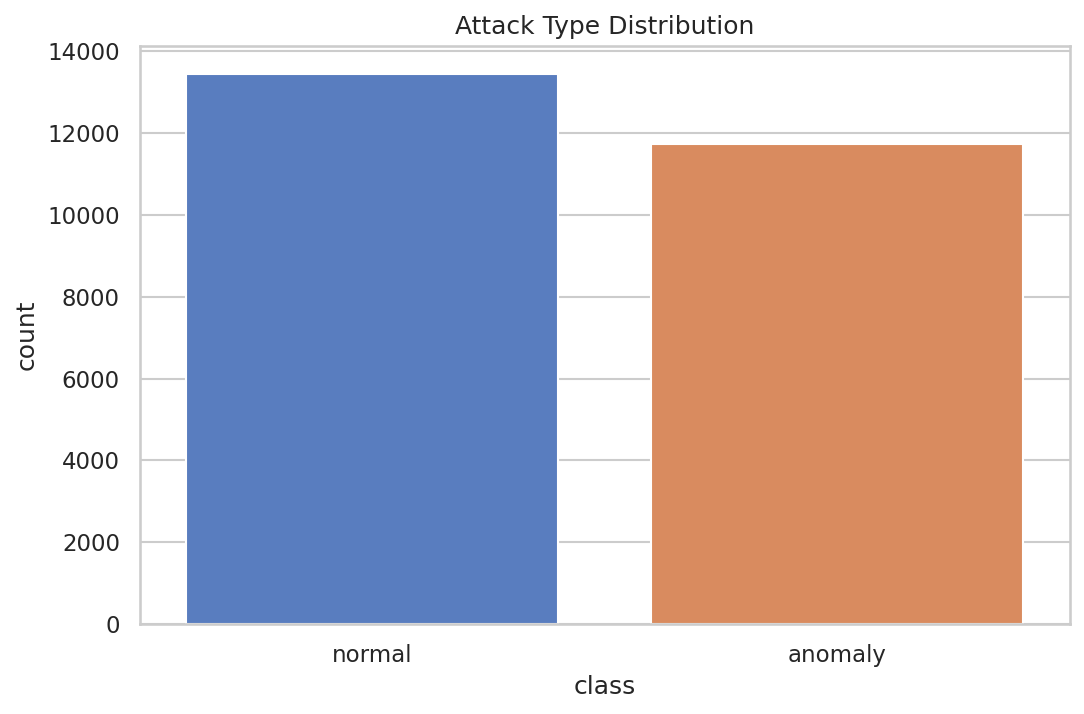

Saved: /mnt/data/visualizations_output/label_distribution_donut.png


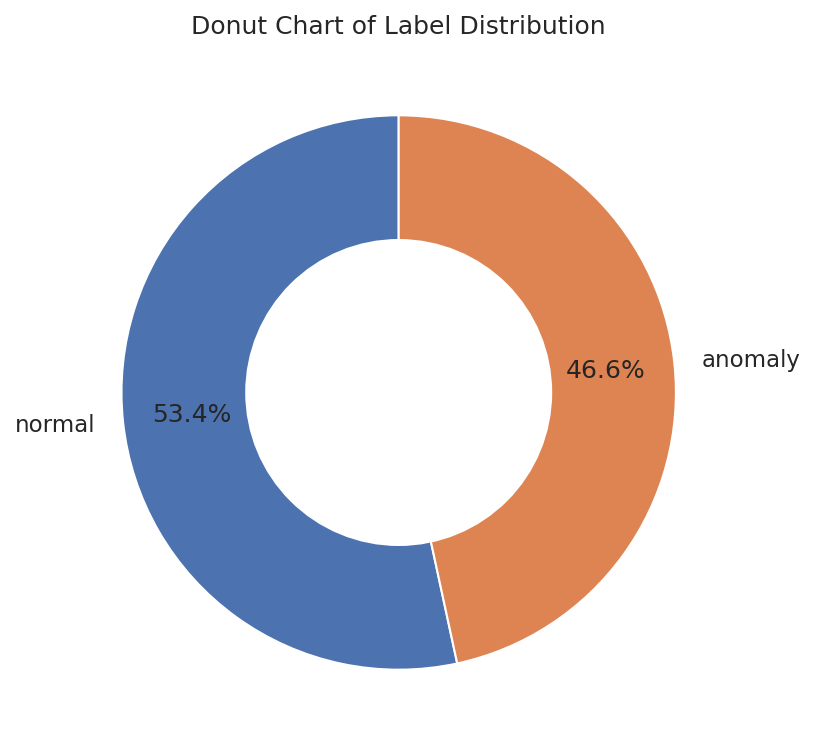

Saved: /mnt/data/visualizations_output/feature_distributions_grid.png


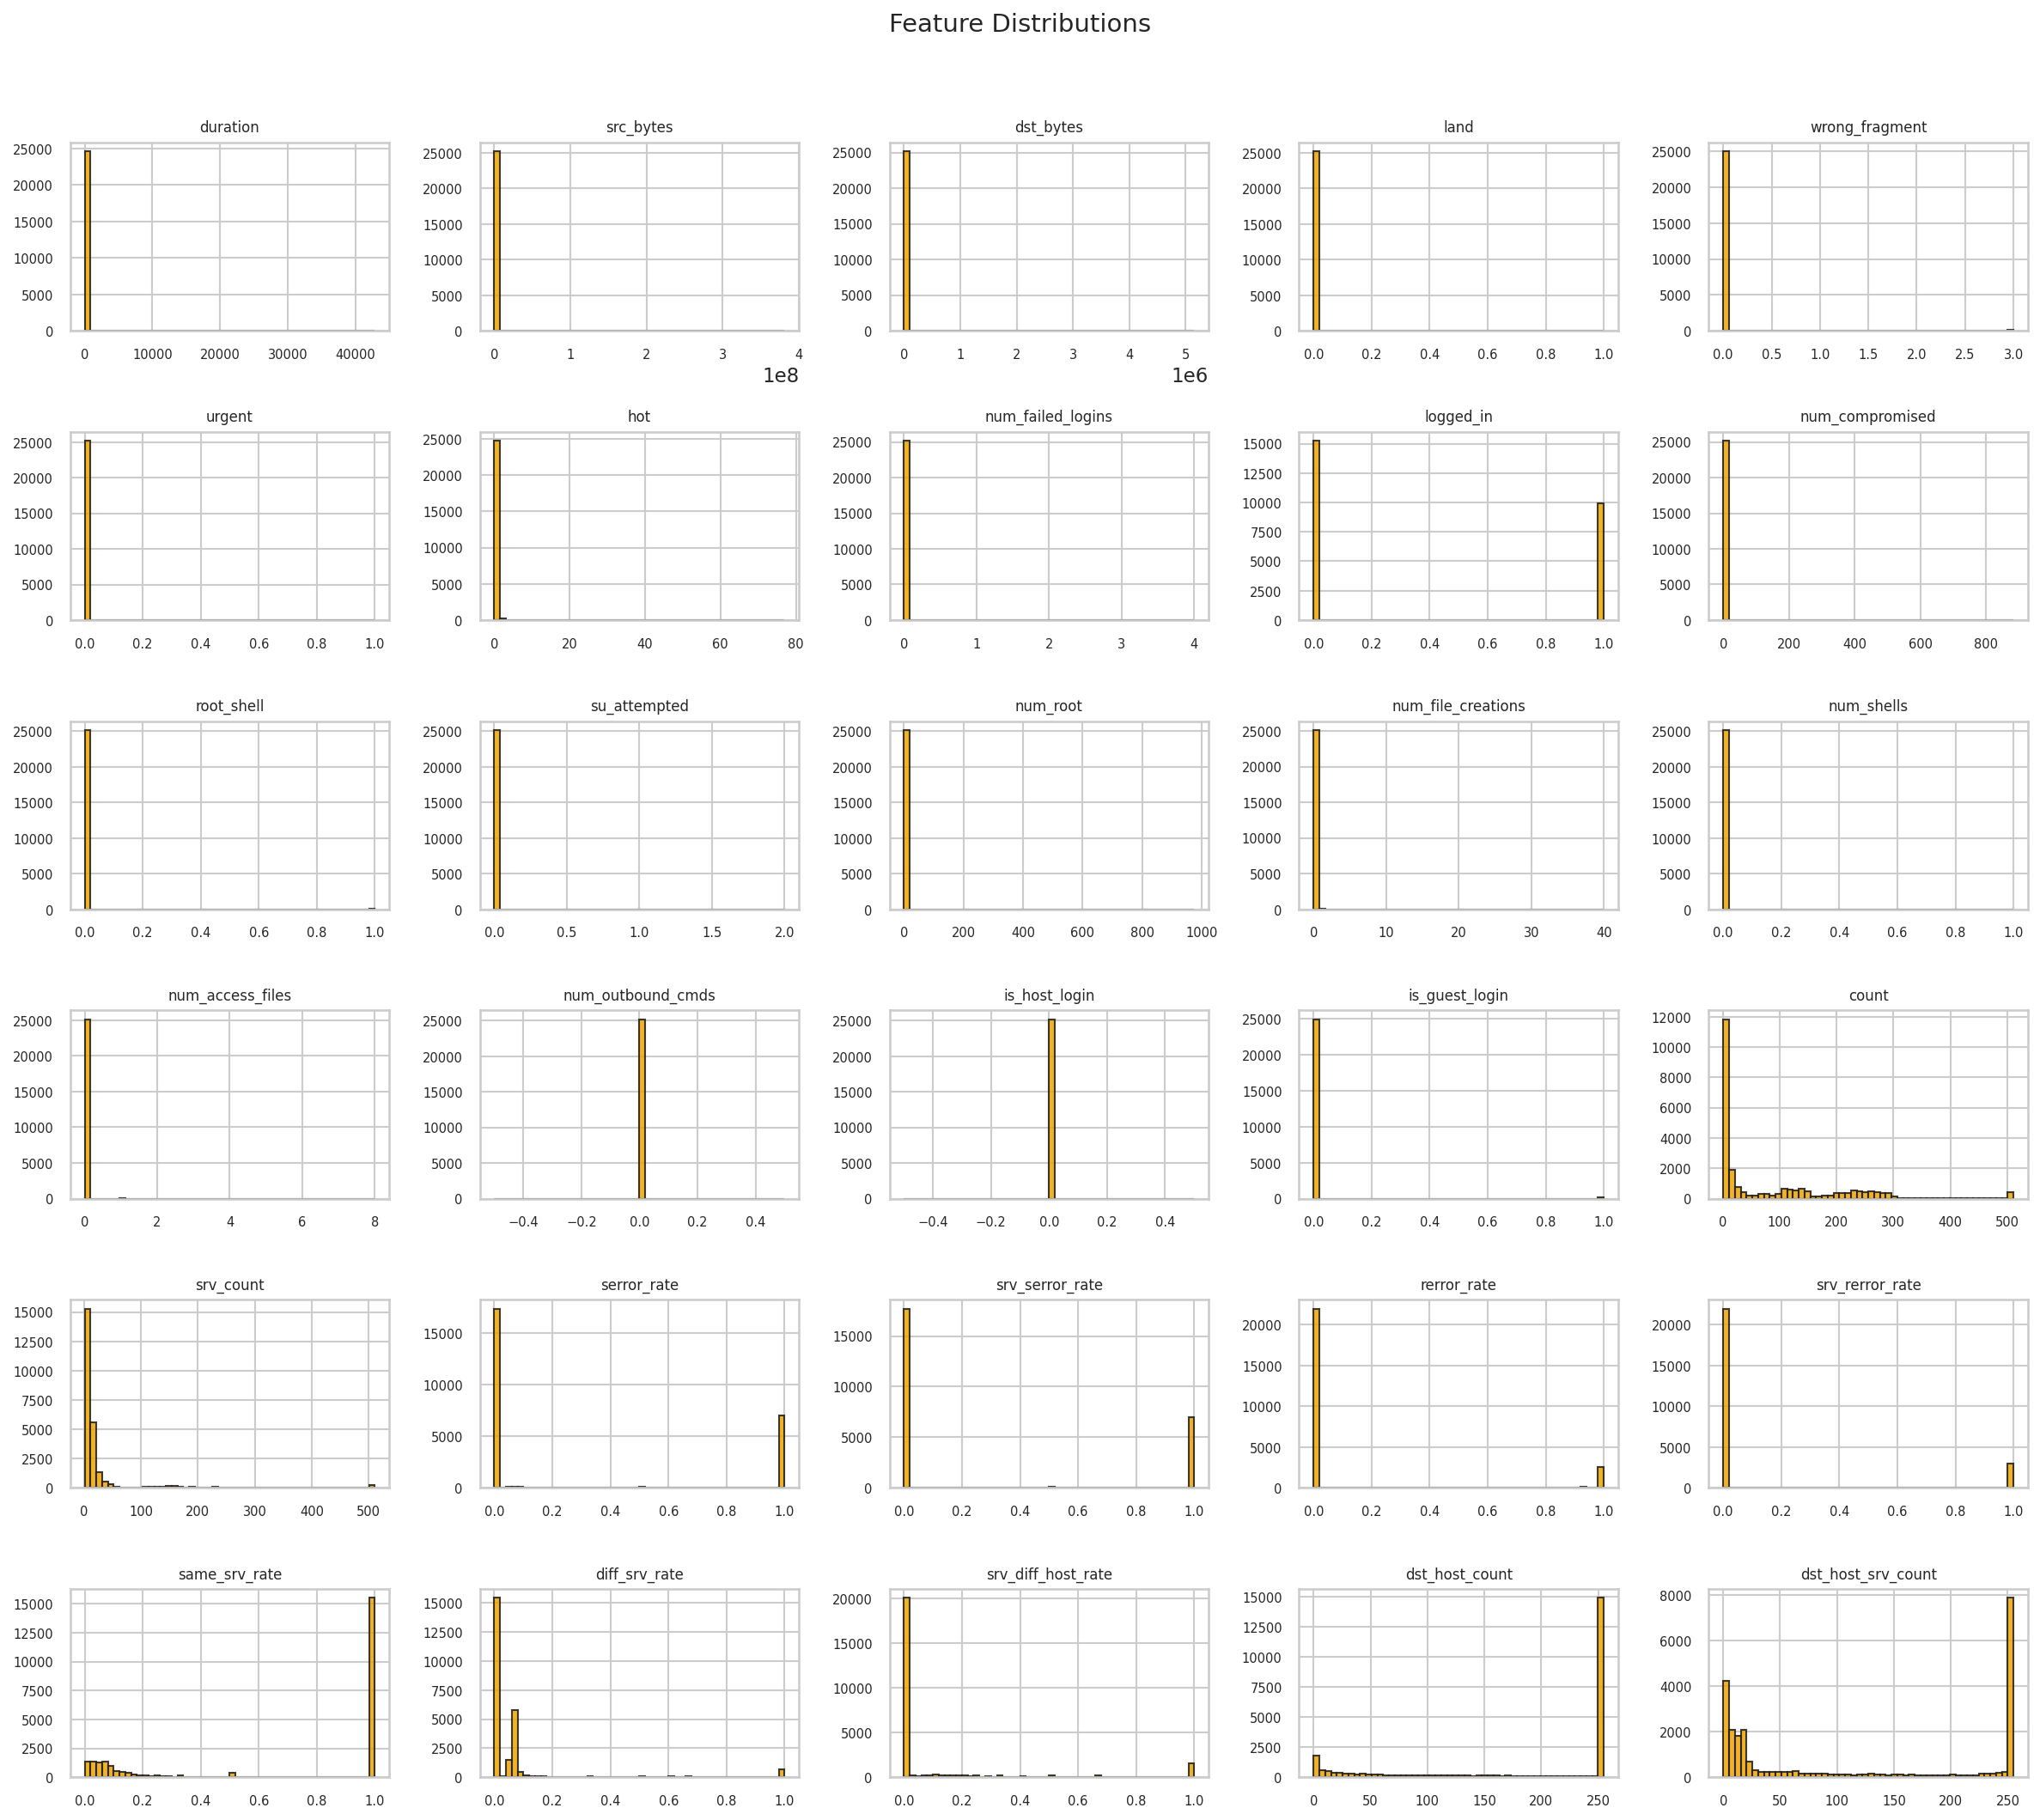

Saved: /mnt/data/visualizations_output/outlier_detection_feature_maxima.png


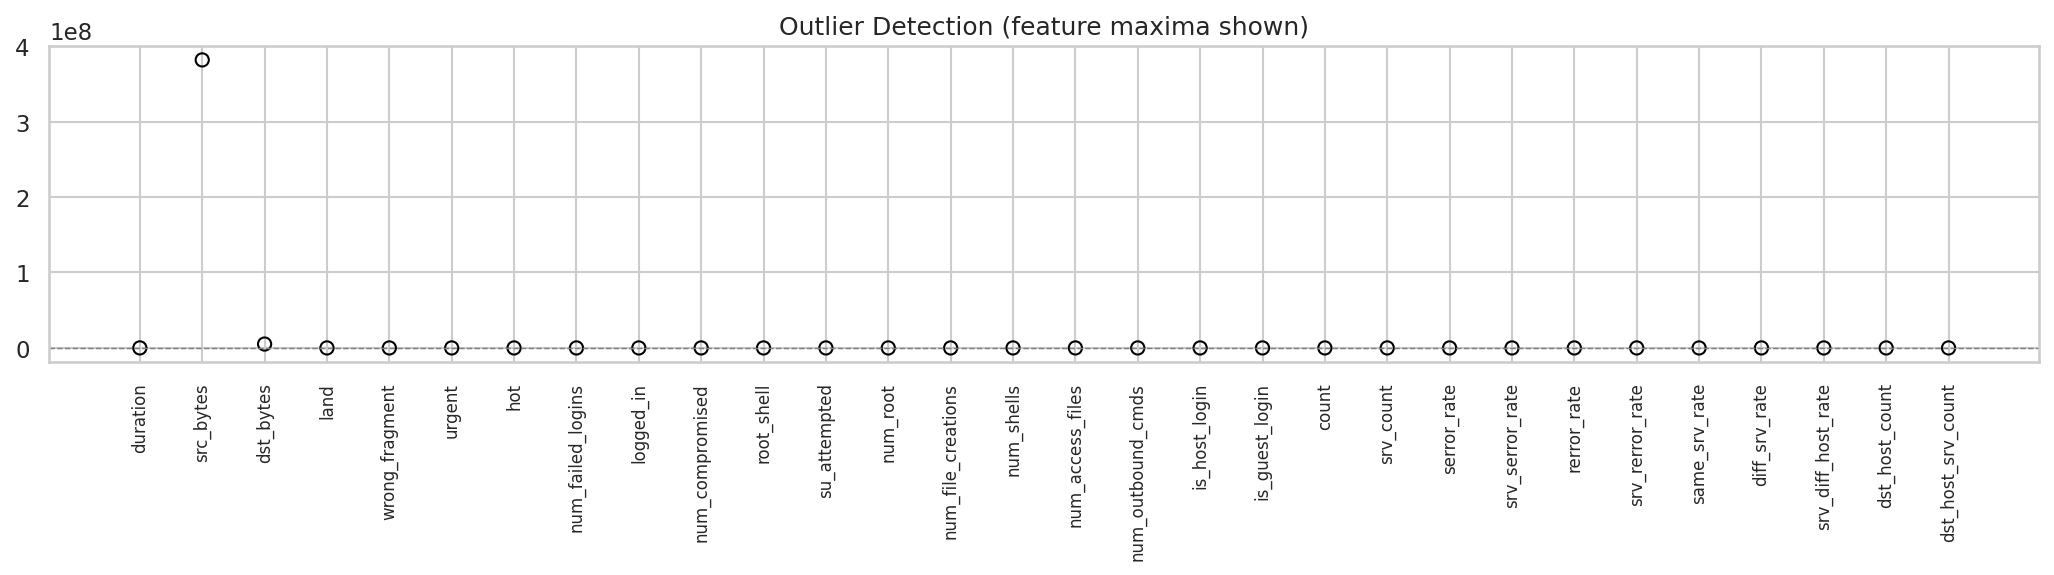

Saved: /mnt/data/visualizations_output/pca_visualization.png


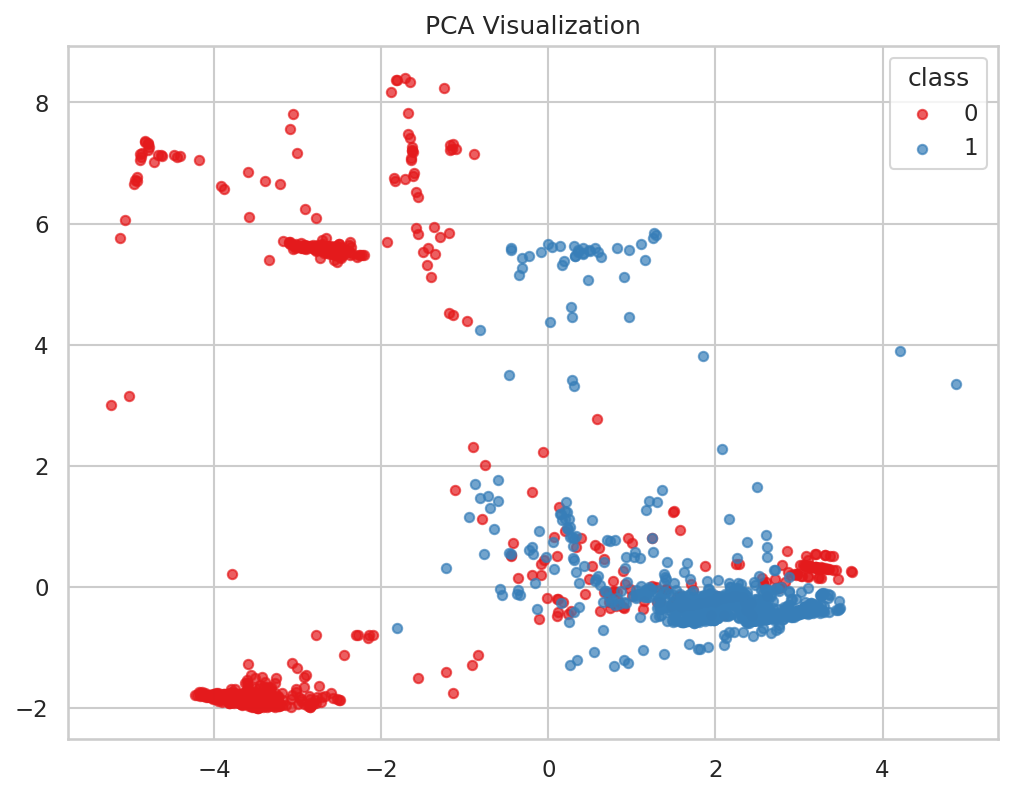

Saved: /mnt/data/visualizations_output/feature_entropy.png


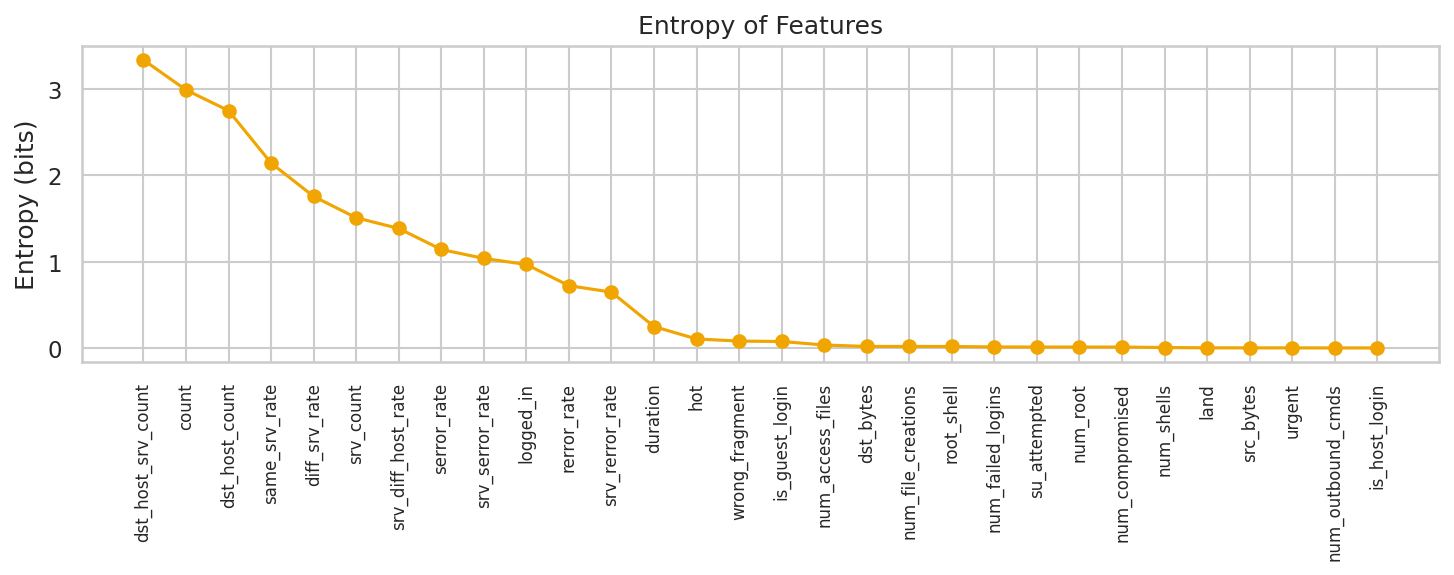

Training RandomForest to compute feature importances (this may take a moment)...
Saved: /mnt/data/visualizations_output/feature_importances_top15.png


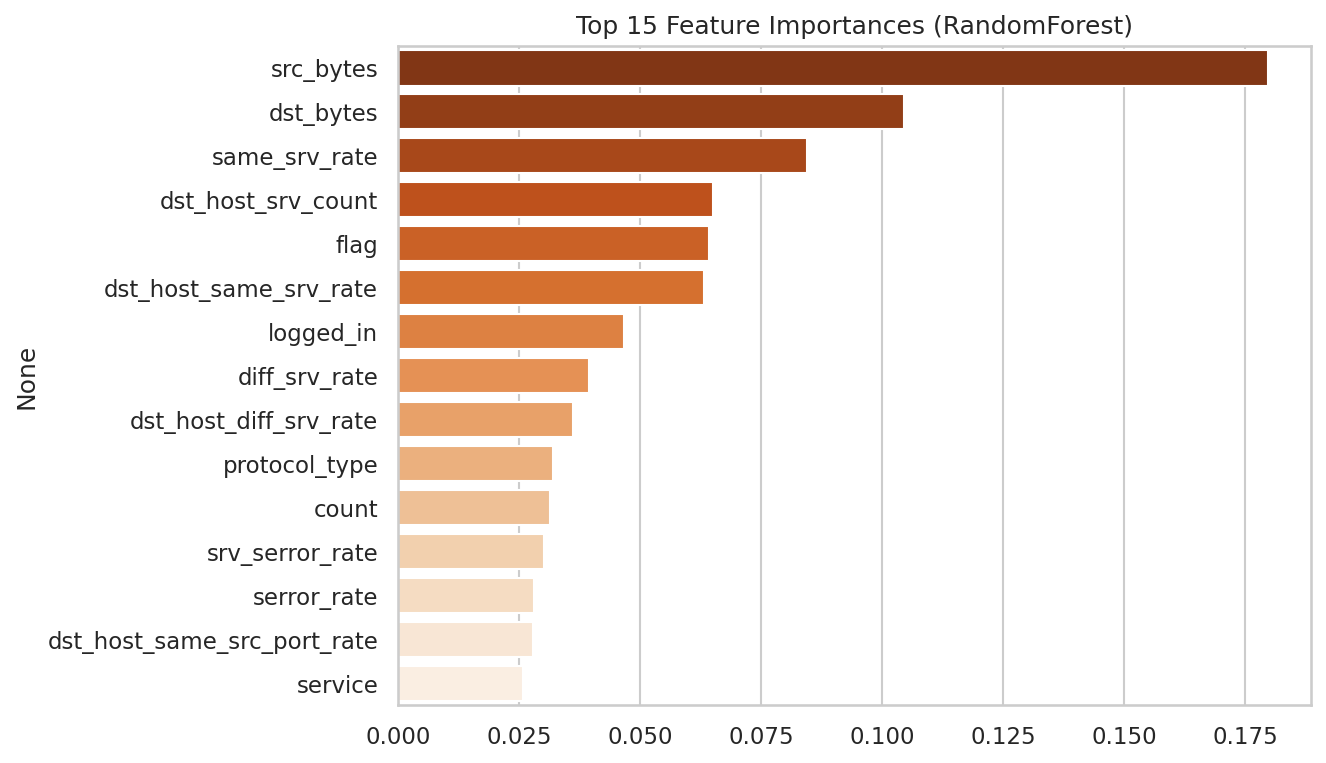

Saved HTML index: /mnt/data/visualizations_output/index.html

All visuals created and saved to: /mnt/data/visualizations_output
If you are in a notebook, images were displayed inline. Otherwise open the files in that directory or open index.html.


In [7]:
# show_all_visuals.py
"""
Generate and display/save all EDA visualizations for the dataset files that
were uploaded to the environment.

Reads:
  - /mnt/data/Train_data.csv   (required)
  - /mnt/data/Test_data.csv    (optional)

Outputs (saved to /mnt/data/visualizations_output/):
  - attack_type_distribution_bar.png
  - label_distribution_donut.png
  - feature_distributions_grid.png
  - outlier_detection_feature_maxima.png
  - pca_visualization.png
  - feature_entropy.png
  - feature_importances_top15.png

If run inside a Jupyter/Colab notebook, images will also be displayed inline.

Dependencies:
  pip install pandas numpy matplotlib seaborn scikit-learn scipy
"""

import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import entropy
from scipy.cluster.hierarchy import linkage, dendrogram

# ---------- CONFIG ----------
TRAIN_CSV = "/content/Train_data.csv"
TEST_CSV = "/content/Test_data.csv"   # optional
OUTDIR = Path("/mnt/data/visualizations_output")
OUTDIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

sns.set(style="whitegrid", context="notebook", rc={"figure.dpi":150})

# ---------- HELPERS ----------
def save_fig(fig, fname):
    path = OUTDIR / fname
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print("Saved:", path)
    return str(path)

def encode_df(df, encoders=None):
    df = df.copy()
    if encoders is None:
        encoders = {}
        fit = True
    else:
        fit = False
    for c in df.select_dtypes(include=['object']).columns:
        if fit:
            le = LabelEncoder()
            df[c] = le.fit_transform(df[c].astype(str))
            encoders[c] = le
        else:
            if c in encoders:
                df[c] = encoders[c].transform(df[c].astype(str))
            else:
                le = LabelEncoder()
                df[c] = le.fit_transform(df[c].astype(str))
                encoders[c] = le
    return df, encoders

def feature_entropy(series, bins=30):
    vals = series.dropna().values
    if len(np.unique(vals)) <= 1:
        return 0.0
    hist, _ = np.histogram(vals, bins=bins)
    if hist.sum() == 0:
        return 0.0
    hist = hist / hist.sum()
    return entropy(hist, base=2)

def try_display_image(path):
    """
    Try to display an image inline (works in Jupyter environments). Silently skip otherwise.
    """
    try:
        from IPython.display import Image, display
        display(Image(filename=str(path)))
    except Exception:
        pass

# ---------- LOAD DATA ----------
if not Path(TRAIN_CSV).exists():
    raise FileNotFoundError(f"Train file not found at {TRAIN_CSV}")

print("Loading:", TRAIN_CSV)
df = pd.read_csv(TRAIN_CSV)
print("Train shape:", df.shape)

test_df = None
if Path(TEST_CSV).exists():
    try:
        test_df = pd.read_csv(TEST_CSV)
        print("Test shape:", test_df.shape)
    except Exception as e:
        print("Could not read Test CSV:", e)

# ---------- PREP ----------
numeric = df.select_dtypes(include=[np.number]).copy()
num_cols = [c for c in numeric.columns if c != 'class'] if 'class' in numeric.columns else numeric.columns.tolist()
plot_cols = num_cols[:30]  # limit to top 30 features for grid & entropy

# ---------- 1) Attack Type Distribution (bar + donut) ----------
if 'class' in df.columns:
    counts = df['class'].value_counts()
    # Bar
    fig = plt.figure(figsize=(8,5))
    ax = fig.add_subplot(1,1,1)
    sns.barplot(x=counts.index.astype(str), y=counts.values, palette="muted", ax=ax)
    ax.set_title("Attack Type Distribution")
    ax.set_xlabel("class")
    ax.set_ylabel("count")
    save_fig(fig, "attack_type_distribution_bar.png")
    try_display_image(OUTDIR/"attack_type_distribution_bar.png")

    # Donut
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(1,1,1)
    wedges, texts, autotexts = ax.pie(counts.values, labels=counts.index.astype(str),
                                      autopct="%1.1f%%", startangle=90, pctdistance=0.75)
    centre_circle = plt.Circle((0,0),0.55, fc='white')
    fig.gca().add_artist(centre_circle)
    ax.set_title("Donut Chart of Label Distribution")
    save_fig(fig, "label_distribution_donut.png")
    try_display_image(OUTDIR/"label_distribution_donut.png")
else:
    print("Warning: 'class' column not found — skipping class distribution plots.")

# ---------- 2) Feature Distributions Grid (histograms) ----------
if len(plot_cols) > 0:
    cols_per_row = 5
    rows = int(np.ceil(len(plot_cols) / cols_per_row))
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row*3.2, rows*2.4))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        ax = axes[i]
        vals = numeric[col].dropna().values
        if len(vals) > 0:
            ax.hist(vals, bins=50, color="#f0a500", edgecolor="k", alpha=0.85)
        ax.set_title(col, fontsize=8)
        ax.tick_params(axis='both', which='major', labelsize=7)
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    fig.suptitle("Feature Distributions", fontsize=14)
    plt.tight_layout(rect=[0,0,1,0.96])
    save_fig(fig, "feature_distributions_grid.png")
    try_display_image(OUTDIR/"feature_distributions_grid.png")
else:
    print("No numeric features to plot distributions.")

# ---------- 3) Outlier detection (max per feature scatter) ----------
if len(plot_cols) > 0:
    max_vals = numeric[plot_cols].max().fillna(0)
    fig = plt.figure(figsize=(14,4))
    ax = fig.add_subplot(1,1,1)
    x = np.arange(len(max_vals))
    y = max_vals.values
    ax.scatter(x, y, facecolors='none', edgecolors='black', s=40)
    ax.set_xticks(x)
    ax.set_xticklabels(max_vals.index, rotation=90, fontsize=8)
    ax.set_title("Outlier Detection (feature maxima shown)")
    ax.axhline(0, linestyle='--', linewidth=0.7, color='gray')
    plt.tight_layout()
    save_fig(fig, "outlier_detection_feature_maxima.png")
    try_display_image(OUTDIR/"outlier_detection_feature_maxima.png")

# ---------- 4) PCA visualization ----------
try:
    sample = df.sample(n=min(2000, len(df)), random_state=RANDOM_STATE)
    sample_enc, encs = encode_df(sample)
    num_for_pca = sample_enc.select_dtypes(include=[np.number]).copy()
    if 'class' in num_for_pca.columns: num_for_pca = num_for_pca.drop(columns=['class'])
    scaler = StandardScaler()
    X_pca = scaler.fit_transform(num_for_pca.fillna(0))
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pc = pca.fit_transform(X_pca)
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(1,1,1)
    if 'class' in sample_enc.columns:
        classes = sample_enc['class'].values
        uniq = np.unique(classes)
        palette = sns.color_palette("Set1", n_colors=len(uniq))
        for i,c in enumerate(uniq):
            mask = classes == c
            ax.scatter(pc[mask,0], pc[mask,1], s=20, alpha=0.7, label=str(c), color=palette[i])
        ax.legend(title='class')
    else:
        ax.scatter(pc[:,0], pc[:,1], s=10, alpha=0.8)
    ax.set_title("PCA Visualization")
    save_fig(fig, "pca_visualization.png")
    try_display_image(OUTDIR/"pca_visualization.png")
except Exception as e:
    print("PCA visualization failed:", e)

# ---------- 5) Feature entropy plot ----------
if len(plot_cols) > 0:
    ent = {c: feature_entropy(df[c]) for c in plot_cols}
    ent_s = pd.Series(ent).sort_values(ascending=False)
    top_ent = ent_s.head(30)
    fig = plt.figure(figsize=(10,4))
    ax = fig.add_subplot(1,1,1)
    ax.plot(np.arange(len(top_ent)), top_ent.values, marker='o', color="#f0a500")
    ax.set_xticks(np.arange(len(top_ent)))
    ax.set_xticklabels(top_ent.index, rotation=90, fontsize=8)
    ax.set_ylabel("Entropy (bits)")
    ax.set_title("Entropy of Features")
    plt.tight_layout()
    save_fig(fig, "feature_entropy.png")
    try_display_image(OUTDIR/"feature_entropy.png")
else:
    print("No features available for entropy computation.")

# ---------- 6) Feature importances (RandomForest) ----------
if 'class' in df.columns:
    try:
        df_enc, encs_all = encode_df(df)
        X = df_enc.drop(columns=['class'])
        y = df_enc['class']
        rf = RandomForestClassifier(n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1)
        print("Training RandomForest to compute feature importances (this may take a moment)...")
        rf.fit(X.fillna(0), y)
        imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
        topk = imp.head(15)
        fig = plt.figure(figsize=(9, max(4, len(topk)*0.35)))
        ax = fig.add_subplot(1,1,1)
        sns.barplot(x=topk.values, y=topk.index, palette="Oranges_r", ax=ax)
        ax.set_title("Top 15 Feature Importances (RandomForest)")
        plt.tight_layout()
        save_fig(fig, "feature_importances_top15.png")
        try_display_image(OUTDIR/"feature_importances_top15.png")
    except Exception as e:
        print("Could not compute RandomForest importances:", e)
else:
    print("Skipping feature importances — 'class' not present.")

# ---------- 7) (Optional) Save a simple HTML index with links to images ----------
html_path = OUTDIR / "index.html"
with open(html_path, "w", encoding="utf-8") as f:
    f.write("<html><head><meta charset='utf-8'><title>EDA Visuals</title></head><body>\n")
    for img in sorted(OUTDIR.glob("*.png")):
        f.write(f"<h3>{img.name}</h3>\n")
        f.write(f"<img src='{img.name}' style='max-width:900px;'><br/>\n")
    f.write("</body></html>\n")
print("Saved HTML index:", html_path)

print("\nAll visuals created and saved to:", OUTDIR)
print("If you are in a notebook, images were displayed inline. Otherwise open the files in that directory or open index.html.")
